In [111]:
import cv2
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread('road.bmp', cv2.IMREAD_GRAYSCALE)

# Average Filter

3x3 neighborhood (z_k):
 [[50 53 68]
 [52 34 35]
 [43 51 71]]
Weights (w_k):
 [[1 1 1]
 [1 1 1]
 [1 1 1]]
Sum(w_k * z_k) = 457.0
R = (1/9) * Sum = 50.77777777777777
Manual filtered value at center pixel (129,129): 51
cv.blur value at same pixel: 51


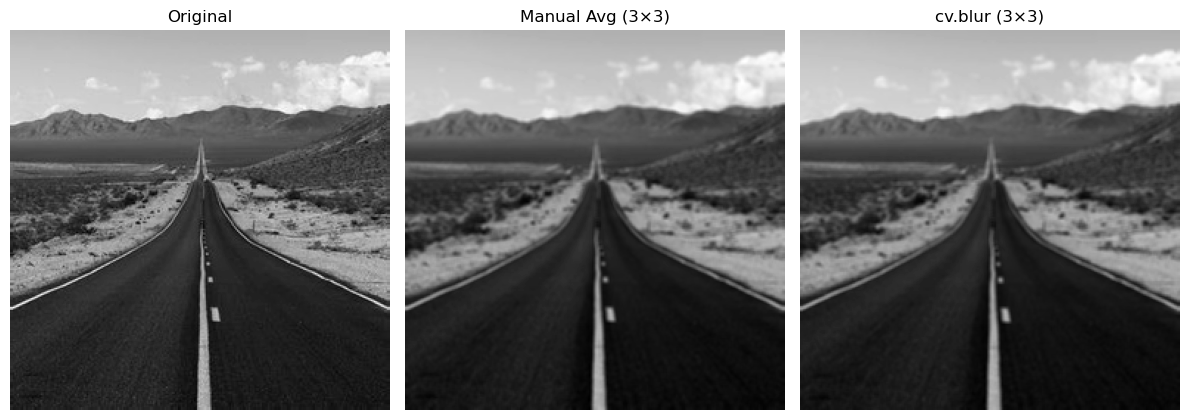

In [ ]:
# average filtering
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

gray = img
gray2 = img

gray = cv.copyMakeBorder(
    gray, 
    top=1, bottom=1, left=1, right=1, 
    borderType=cv.BORDER_REPLICATE   # replicate edges outward
)


h, w = gray.shape
y, x = h // 2, w // 2

# Extract 3x3 neighborhood
patch = gray[y-1:y+2, x-1:x+2].astype(np.float32)

# 3x3 standard average mask
W = np.ones((3,3), np.float32)           
R = (1/9.0) * np.sum(W * patch)          # R = (1/9) * sum_k (w_k * z_k)

print("3x3 neighborhood (z_k):\n", patch.astype(int))
print("Weights (w_k):\n", W.astype(int))
print("Sum(w_k * z_k) =", np.sum(W * patch))
print("R = (1/9) * Sum =", R)
print(f"Manual filtered value at center pixel ({y},{x}): {int(round(R))}")

# Compare the same location with OpenCV's blur
opencv_center = cv.blur(gray, (3,3))[y, x]
print("cv.blur value at same pixel:", int(opencv_center))

kernel = np.ones((3,3), np.float32) / 9.0
manual_filtered = cv.filter2D(gray, ddepth=-1, kernel=kernel)

# OpenCV average filter
opencv_filtered = cv.blur(gray2, (3,3))

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(manual_filtered, cmap='gray'); plt.title("Manual Avg (3×3)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(opencv_filtered, cmap='gray'); plt.title("cv.blur (3×3)"); plt.axis("off")
plt.tight_layout(); plt.show()

# Weighted Average

3x3 neighborhood (z_k):
 [[50 53 68]
 [52 34 35]
 [43 51 71]]
Weights (w_k):
 [[1 2 1]
 [2 4 2]
 [1 2 1]]
Sum(w_k*z_k) = 750.0
R = (1/16) * Sum = 46.875
Manual weighted avg value at (129,129): 47


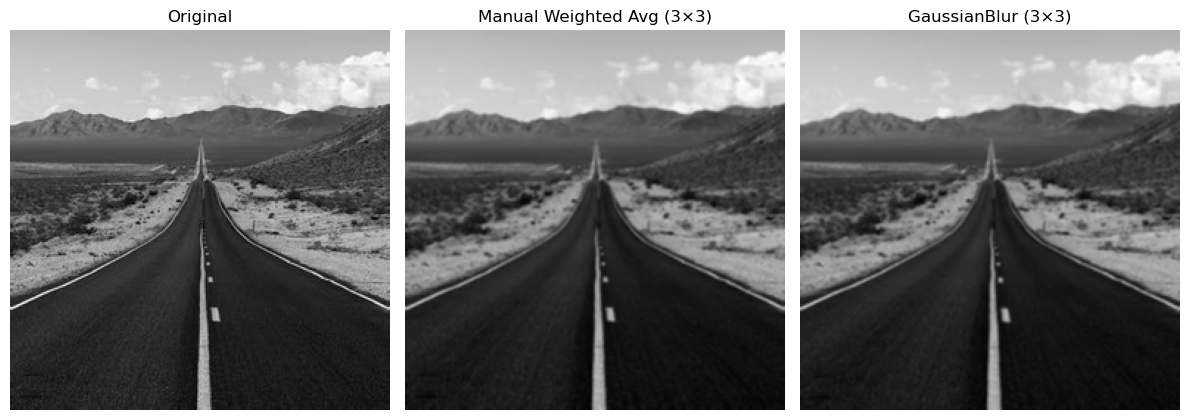

In [ ]:
# weighted average filtering
h, w = gray.shape
y, x = h // 2, w // 2  # center pixel

patch = gray[y-1:y+2, x-1:x+2].astype(np.float32)

# Weighted kernel
W = np.array([[1,2,1],
              [2,4,2],
              [1,2,1]], dtype=np.float32)

R = (1/16.0) * np.sum(W * patch)

print("3x3 neighborhood (z_k):\n", patch.astype(int))
print("Weights (w_k):\n", W.astype(int))
print("Sum(w_k*z_k) =", np.sum(W * patch))
print("R = (1/16) * Sum =", R)
print(f"Manual weighted avg value at ({y},{x}): {int(round(R))}")

kernel = W / 16.0
manual_filtered = cv.filter2D(gray, ddepth=-1, kernel=kernel)

opencv_gaussian = cv.GaussianBlur(gray2, (3,3), sigmaX=0)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(manual_filtered, cmap='gray'); plt.title("Manual Weighted Avg (3×3)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(opencv_gaussian, cmap='gray'); plt.title("GaussianBlur (3×3)"); plt.axis("off")
plt.tight_layout(); plt.show()

# Median

3x3 neighborhood (z_k): [50 53 68 52 34 35 43 51 71]
Sorted values: [34 35 43 50 51 52 53 68 71]
Median value = 51.0
Manual median at (129,129): 51


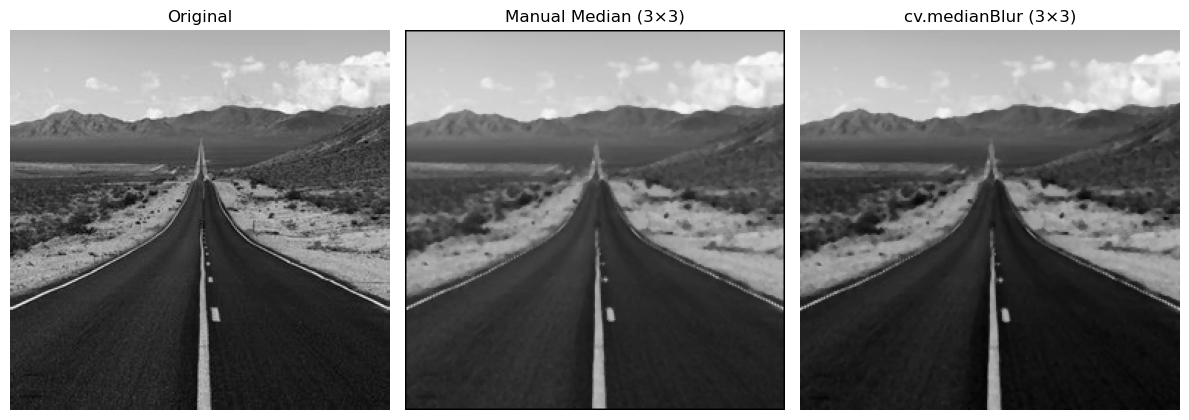

In [ ]:
# median filtering
h, w = gray.shape
y, x = h // 2, w // 2  # center pixel

patch = gray[y-1:y+2, x-1:x+2].flatten()   # 3x3 neighborhood -> 1D array
sorted_vals = np.sort(patch)
R = np.median(patch)

print("3x3 neighborhood (z_k):", patch)
print("Sorted values:", sorted_vals)
print("Median value =", R)
print(f"Manual median at ({y},{x}): {int(R)}")

manual_filtered = np.zeros_like(gray)
for i in range(1, h-1):
    for j in range(1, w-1):
        neighborhood = gray[i-1:i+2, j-1:j+2].flatten()
        manual_filtered[i,j] = np.median(neighborhood)

# OpenCV built-in medianBlur
opencv_filtered = cv.medianBlur(gray2, 3)  # kernel size = 3x3

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(manual_filtered, cmap='gray'); plt.title("Manual Median (3×3)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(opencv_filtered, cmap='gray'); plt.title("cv.medianBlur (3×3)"); plt.axis("off")
plt.tight_layout(); plt.show()

# High Boosting

Center pixel (129,129) calculation:
  f(x,y)       = 34.0
  fhat(x,y)    = 51.0   (3x3 average)
  detail       = f - fhat = -17.0
  g = f + k*(f - fhat) with k=1.8 -> 3.3999999999999986 -> clipped -> 3


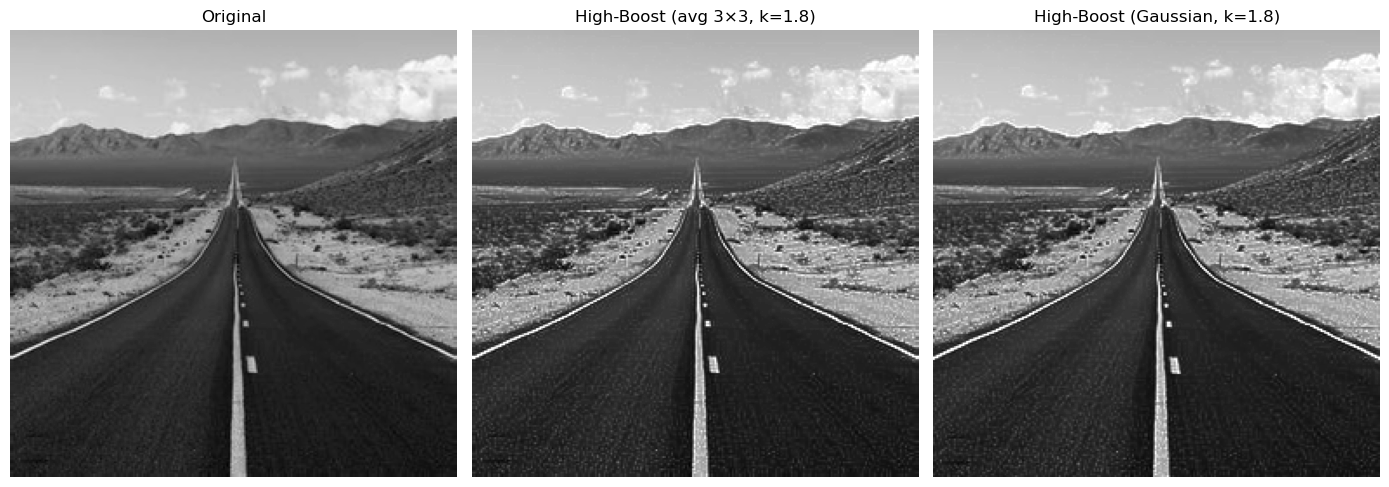

In [ ]:
# high boost filtering
k = 1.8  # boost factor

# Smooth with 3x3 average
avg_kernel = np.ones((3,3), np.float32) / 9.0
smoothed = cv.filter2D(gray, -1, avg_kernel)

# Pick a safe center pixel
h, w = gray.shape
y, x = h // 2, w // 2

f_xy      = float(gray[y, x])
fhat_xy   = float(smoothed[y, x])
detail_xy = f_xy - fhat_xy               # high-frequency (mask)
g_xy      = f_xy + k * detail_xy         # high-boost output (float)
g_xy_cl   = np.clip(round(g_xy), 0, 255) # clamp to 8-bit

print(f"Center pixel ({y},{x}) calculation:")
print(f"  f(x,y)       = {f_xy}")
print(f"  fhat(x,y)    = {fhat_xy}   (3x3 average)")
print(f"  detail       = f - fhat = {detail_xy}")
print(f"  g = f + k*(f - fhat) with k={k} -> {g_xy} -> clipped -> {int(g_xy_cl)}")

# detail = f - smooth(f)
detail = cv.subtract(gray, smoothed)    
# g = f + k*detail
manual_highboost = cv.addWeighted(gray, 1.0, detail, k, 0)  

# Gaussian blur
gauss = cv.GaussianBlur(img, (0,0), sigmaX=1.0)
mask  = cv.subtract(img, gauss)
opencv_highboost = cv.addWeighted(img, 1.0, mask, k, 0)

plt.figure(figsize=(14,5))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(manual_highboost, cmap='gray'); plt.title(f"High-Boost (avg 3×3, k={k})"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(opencv_highboost, cmap='gray'); plt.title(f"High-Boost (Gaussian, k={k})"); plt.axis("off")
plt.tight_layout(); plt.show()

# Laplacian

3x3 neighborhood (z_k):
 [[50 53 68]
 [52 34 35]
 [43 51 71]]
Laplacian kernel K4:
 [[ 1  1  1]
 [ 1 -8  1]
 [ 1  1  1]]
Δ²f(x,y) = sum(K4 * patch) = 151.0
Sharpened center pixel: 0


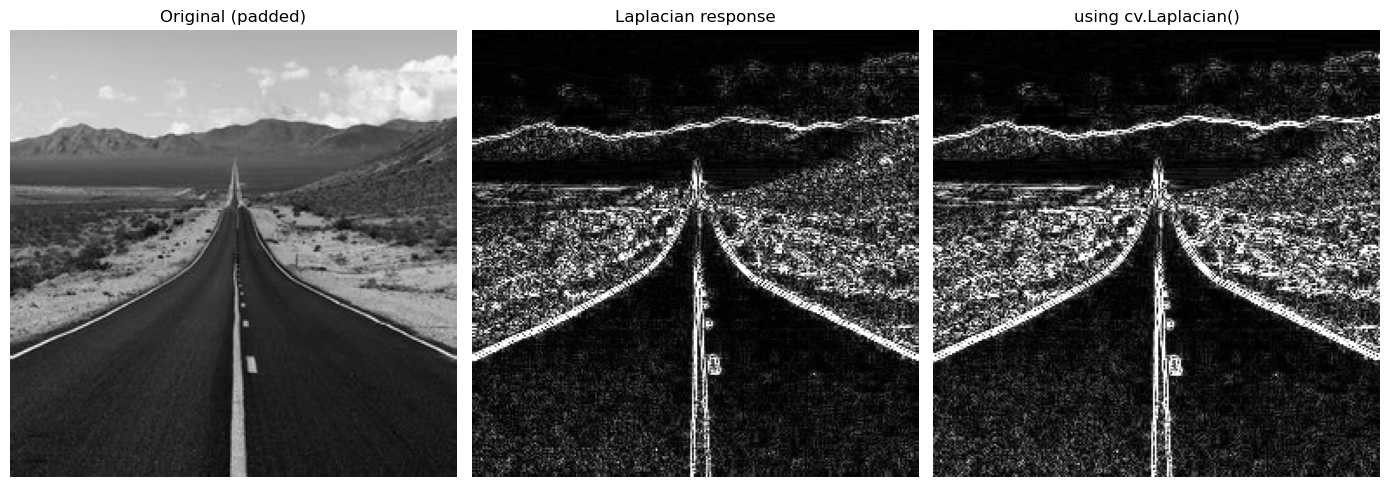

In [ ]:
# Laplacian filtering
K4 = np.array([[1, 1, 1],
               [1,-8, 1],
               [1, 1, 1]], dtype=np.float32)

h, w = gray.shape
y, x = h//2, w//2
patch = gray[y-1:y+2, x-1:x+2].astype(np.float32)

lap_xy = np.sum(K4 * patch)

print("3x3 neighborhood (z_k):\n", patch.astype(int))
print("Laplacian kernel K4:\n", K4.astype(int))
print("Δ²f(x,y) = sum(K4 * patch) =", lap_xy)

g_xy = float(gray[y, x]) - lap_xy
g_xy = int(np.clip(round(g_xy), 0, 255))
print(f"Sharpened center pixel: {g_xy}")

lap_all = cv.filter2D(gray, ddepth=cv.CV_16S, kernel=K4)
lap_all_abs = cv.convertScaleAbs(lap_all)

sharpened = np.clip(gray.astype(np.int16) - lap_all, 0, 255).astype(np.uint8)

lap_cv = cv.Laplacian(img, ddepth=cv.CV_16S, ksize=3)
lap_cv_abs = cv.convertScaleAbs(lap_cv)

plt.figure(figsize=(14,6))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title("Original (padded)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(lap_all_abs, cmap='gray'); plt.title("Laplacian response"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(lap_cv_abs, cmap='gray'); plt.title("using cv.Laplacian()"); plt.axis("off")
plt.tight_layout(); plt.show()